# Benchmarking de Detecção Acústica de Anomalias (Cenário 2: API REST Cloud)
**Objetivo:** Validar a eficácia de modelos supervisionados e não supervisionados no processamento em lote de áudio industrial (16s).
**Etapas:** Geração de Dados -> DSP & RPCA -> Modelagem -> Explicabilidade (XAI) -> Benchmarking.

In [6]:
# Instalação de pacotes necessários (XGBoost geralmente já vem no Colab, mas garantimos aqui)
!pip install -q librosa xgboost seaborn torch

import os
import time
import pywt
import torch
import librosa
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import librosa.display
import torch.optim as optim
from google.colab import drive
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Configurações de plotagem
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="deep")

## 1.0 Dataset real
Captação aúdio de 16 segundos de áudio (taxa de amostragem de 16kHz). O sinal é composto por um ruído de fundo contínuo (maquinário normal e anômalo).

In [2]:
# 1. Montar o Google Drive
drive.mount('/content/drive')

# 2. O SEU Caminho Raiz
BASE_PATH = '/content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio'

def load_only_real_audios(base_path, target_sr=16000):
    dados_audio = []
    rotulos = []

    # Definimos estritamente as únicas pastas que o Python tem permissão para abrir
    pastas_reais = {'normal': 0, 'anomaly': 1}

    print("Iniciando varredura estrita (ignorando dados sintéticos)...\n")

    for nome_pasta, valor_rotulo in pastas_reais.items():
        # Ele monta o caminho exato: .../Arquivos de audio/normal
        caminho_exato = os.path.join(base_path, nome_pasta)

        if not os.path.exists(caminho_exato):
            print(f"  [ERRO] A pasta {nome_pasta} não foi encontrada dentro de {base_path}")
            continue

        # Puxa apenas os áudios que estão estritamente dentro da subpasta
        arquivos = [f for f in os.listdir(caminho_exato) if f.endswith(('.wav', '.flac', '.mp3'))]
        print(f"  -> Lendo {len(arquivos)} arquivos estritamente reais da pasta: '{nome_pasta}'")

        for arquivo in arquivos:
            caminho_arquivo = os.path.join(caminho_exato, arquivo)

            # Carrega o áudio e força a taxa de amostragem padronizada
            signal, sr = librosa.load(caminho_arquivo, sr=target_sr)

            dados_audio.append(signal)
            rotulos.append(valor_rotulo)

    return dados_audio, np.array(rotulos), target_sr

# 3. Executar o carregamento
X_raw_list, y_raw, sr_global = load_only_real_audios(BASE_PATH)

if len(X_raw_list) > 0:
    print(f"\nSucesso! {len(X_raw_list)} áudios carregados na memória.")
    print(f"Frequência de amostragem cravada em: {sr_global} Hz.")
else:
    print("\nNenhum áudio carregado. Verifique os nomes das pastas.")

Mounted at /content/drive
Iniciando varredura estrita (ignorando dados sintéticos)...

  -> Lendo 16 arquivos estritamente reais da pasta: 'normal'
  -> Lendo 9 arquivos estritamente reais da pasta: 'anomaly'

Sucesso! 25 áudios carregados na memória.
Frequência de amostragem cravada em: 16000 Hz.


# 1.1 Visualização da onda sonora em estado bruto (Normal/Anômala)

Extraindo amostras para visualização...


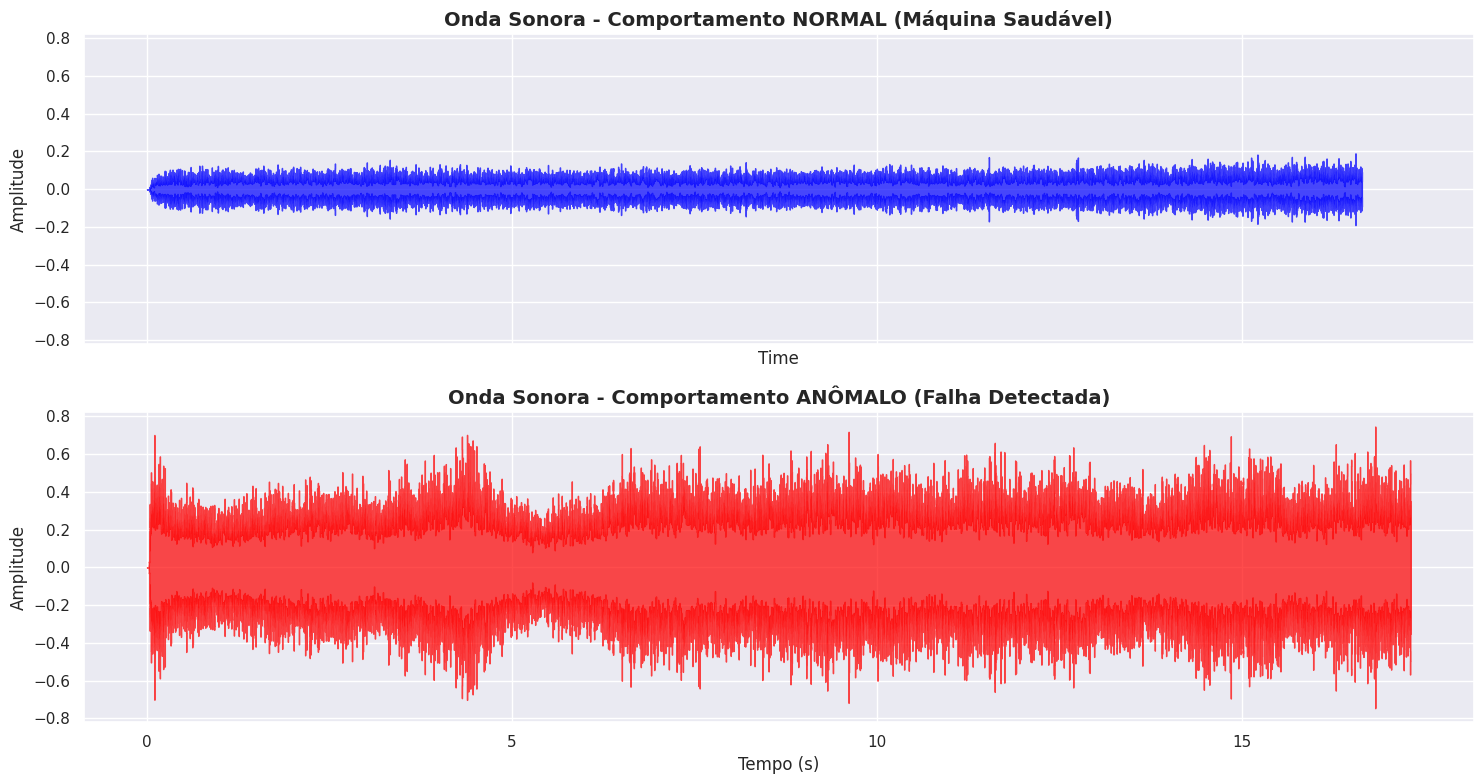

In [3]:
print("Extraindo amostras para visualização...")

# 1. A PONTE: Pescando os áudios reais da memória
# np.where procura onde estão os normais (0) e as anomalias (1) na sua lista y_raw
idx_normal = np.where(y_raw == 0)[0][0]   # Pega o 1º áudio normal que encontrar
idx_anomaly = np.where(y_raw == 1)[0][0]  # Pega o 1º áudio anômalo que encontrar

# Salva nas variáveis exatas que o seu código de gráfico estava pedindo
normal_signal = X_raw_list[idx_normal]
anomaly_signal = X_raw_list[idx_anomaly]
sr = sr_global

# =========================================================
# 2. A PLOTAGEM
# =========================================================
fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True, sharey=True)

# Onda Sonora do Áudio Normal
librosa.display.waveshow(y=normal_signal, sr=sr, ax=ax[0], color='blue', alpha=0.7)
ax[0].set_title('Onda Sonora - Comportamento NORMAL (Máquina Saudável)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Amplitude')

# Onda Sonora do Áudio Anômalo
librosa.display.waveshow(y=anomaly_signal, sr=sr, ax=ax[1], color='red', alpha=0.7)
ax[1].set_title('Onda Sonora - Comportamento ANÔMALO (Falha Detectada)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Tempo (s)')
ax[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# 1.2 Visualização da onda sonora usando CWT (Normal/Anômala)

Calculando e gerando os Escalogramas CWT (Visão de Tempo-Escala)...
Nota: A CWT é processada ponto a ponto! Lendo apenas 2 segundos para proteger a memória RAM.


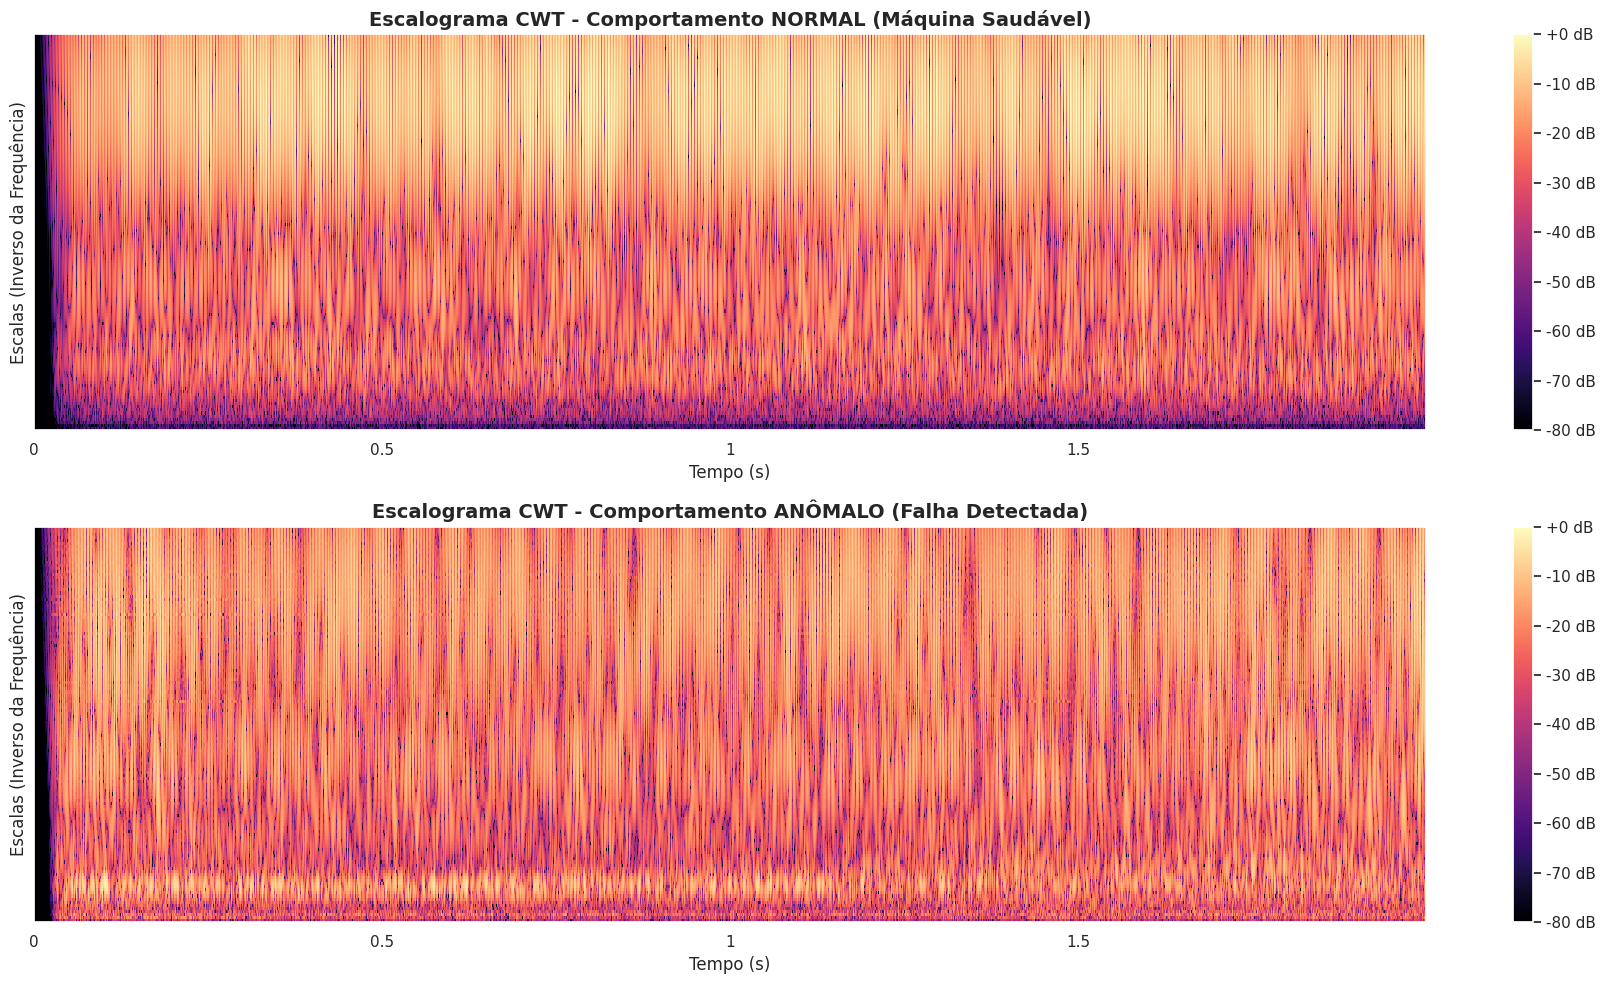

In [7]:
print("Calculando e gerando os Escalogramas CWT (Visão de Tempo-Escala)...")
print("Nota: A CWT é processada ponto a ponto! Lendo apenas 2 segundos para proteger a memória RAM.")

# --- TRAVA DE SEGURANÇA (Para não explodir a memória do Colab) ---
# Pegamos apenas os primeiros 2 segundos (2 * 16000 Hz = 32.000 pontos)
limit = int(2 * sr_global)
normal_signal_cut = normal_signal[:limit]
anomaly_signal_cut = anomaly_signal[:limit]

# Definindo as Escalas (Quanto menor a escala, MAIOR a frequência / mais agudo)
scales = np.arange(1, 129)
waveletname = 'morl' # 'Morlet' é a Wavelet padrão-ouro para análise de áudio industrial

# 1. Calcular a CWT para o áudio normal
# pywt.cwt retorna a matriz de coeficientes e as frequências correspondentes
coef_normal, freqs_normal = pywt.cwt(normal_signal_cut, scales, waveletname, sampling_period=1/sr_global)
cwt_db_normal = librosa.amplitude_to_db(np.abs(coef_normal), ref=np.max)

# 2. Calcular a CWT para o áudio anômalo
coef_anomaly, freqs_anomaly = pywt.cwt(anomaly_signal_cut, scales, waveletname, sampling_period=1/sr_global)
cwt_db_anomaly = librosa.amplitude_to_db(np.abs(coef_anomaly), ref=np.max)

# 3. Visualizar os Escalogramas (CWT)
fig, ax = plt.subplots(2, 1, figsize=(18, 10))

# Plot do Normal
# Usamos hop_length=1 porque a CWT não tem "pulos", ela é ponto a ponto!
img1 = librosa.display.specshow(cwt_db_normal, sr=sr_global, hop_length=1, x_axis='time', ax=ax[0], cmap='magma')
ax[0].set_title('Escalograma CWT - Comportamento NORMAL (Máquina Saudável)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Escalas (Inverso da Frequência)')
ax[0].set_xlabel('Tempo (s)')
fig.colorbar(img1, ax=ax[0], format='%+2.0f dB')

# Plot da Anomalia
img2 = librosa.display.specshow(cwt_db_anomaly, sr=sr_global, hop_length=1, x_axis='time', ax=ax[1], cmap='magma')
ax[1].set_title('Escalograma CWT - Comportamento ANÔMALO (Falha Detectada)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Escalas (Inverso da Frequência)')
ax[1].set_xlabel('Tempo (s)')
fig.colorbar(img2, ax=ax[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

# 1.3. Criação das janelas deslizantes.

In [8]:
# 1. Função de Janela Deslizante
def apply_sliding_window_to_list(audio_list, labels_list, sr=16000, window_size=2, overlap=0.5):
    step = int(window_size * sr * (1 - overlap))
    w_len = int(window_size * sr)
    all_segments, all_labels = [], []

    print("Fatiando os áudios reais com Janela Deslizante...")
    for i, audio in enumerate(audio_list):
        label = labels_list[i]
        if len(audio) < w_len:
            audio = np.pad(audio, (0, w_len - len(audio)))

        for start in range(0, len(audio) - w_len + 1, step):
            all_segments.append(audio[start : start + w_len])
            all_labels.append(label)

    return np.array(all_segments), np.array(all_labels)

# 2. Extração de Características
def extract_features_cwt(X_segments, sr=16000):
    feats_cwt = []
    feats_stat = []

    scales = np.arange(1, 129) # 128 escalas de Wavelet
    waveletname = 'morl'

    print("Extraindo Escalogramas CWT e MFCCs (Isso pode demorar um pouco mais)...")
    for audio in X_segments:
        coef, _ = pywt.cwt(audio, scales, waveletname, sampling_period=1/sr)
        cwt_matrix = np.abs(coef)
        cwt_db = librosa.amplitude_to_db(cwt_matrix, ref=np.max)

        # COMPRESSÃO INTELIGENTE: Saltamos de 500 em 500 pontos no tempo
        # Isso reduz os 32.000 pontos do tempo para exatamente 64 "frames" (32000/500 = 64)
        cwt_db_reduced = cwt_db[:, ::500]

        # Trava de segurança para garantir estritamente 64 colunas de largura
        if cwt_db_reduced.shape[1] > 64:
            cwt_db_reduced = cwt_db_reduced[:, :64]
        else:
            cwt_db_reduced = np.pad(cwt_db_reduced, ((0,0), (0, 64 - cwt_db_reduced.shape[1])))

        feats_cwt.append(cwt_db_reduced[np.newaxis, ...])

        # Mantemos o MFCC (Estatísticas) intacto para o XGBoost
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        feats_stat.append(np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)]))

    return np.array(feats_cwt), np.array(feats_stat)

# 3. Execução
X_win, y_win = apply_sliding_window_to_list(X_raw_list, y_raw, sr=sr_global)

# A variável agora se chama X_cwt!
X_cwt, X_stat = extract_features_cwt(X_win, sr=sr_global)

print(f"\nMatrizes geradas com sucesso para o Treinamento!")
print(f"Total de fatias clássicas (X_stat): {X_stat.shape}")
print(f"Total de matrizes Wavelet (X_cwt): {X_cwt.shape}")

Fatiando os áudios reais com Janela Deslizante...
Extraindo Escalogramas CWT e MFCCs (Isso pode demorar um pouco mais)...

Matrizes geradas com sucesso para o Treinamento!
Total de fatias clássicas (X_stat): (438, 26)
Total de matrizes Wavelet (X_cwt): (438, 1, 128, 64)


## 2. Pré-processamento e Separação de Fontes (RPCA)


1. Calculando a CWT (Extração ponto a ponto das Escalas)...
2. Aplicando RPCA no Escalograma para separação matemática (Aguarde alguns segundos)...


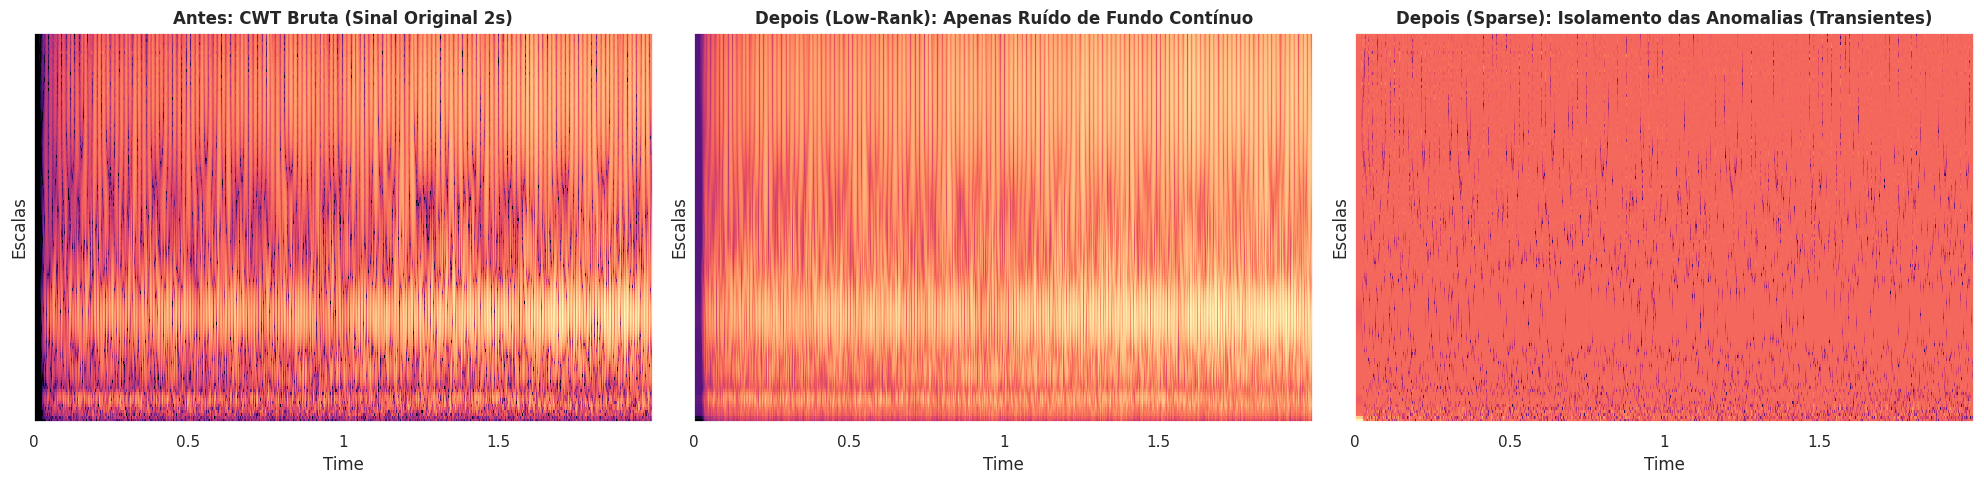

In [9]:
def rpca_ialm(D, mu_multiplier=1.25, max_iter=100, tol=1e-5):
    """Implementação simplificada do Inexact Augmented Lagrange Multiplier para RPCA."""
    Y = D / np.maximum(np.linalg.norm(D, 2), np.linalg.norm(D, np.inf) / 1e-5)
    L = np.zeros_like(D)
    S = np.zeros_like(D)
    mu = 1.25 / np.linalg.norm(D, 2)
    rho = 1.5
    lam = 1 / np.sqrt(np.max(D.shape))

    for _ in range(max_iter):
        temp_T = D - L + (1/mu) * Y
        epsilon = lam / mu
        S = np.maximum(temp_T - epsilon, 0) + np.minimum(temp_T + epsilon, 0)

        temp_L = D - S + (1/mu) * Y
        U, sigmas, V = np.linalg.svd(temp_L, full_matrices=False)
        svp = (sigmas > 1/mu).sum()
        if svp >= 1:
            sigmas = sigmas[:svp] - 1/mu
            L = np.dot(U[:, :svp], np.dot(np.diag(sigmas), V[:svp, :]))
        else:
            L = np.zeros_like(D)

        Z = D - L - S
        Y = Y + mu * Z
        mu = min(mu * rho, mu * 1e7)

        if np.linalg.norm(Z, 'fro') / np.linalg.norm(D, 'fro') < tol:
            break
    return L, S

# --- Conectando os dados reais ---
signal = X_raw_list[-1] # Pegamos uma anomalia (o último áudio da lista)
sr = sr_global

# TRAVA DE SEGURANÇA PARA O RPCA (Para a matemática não estourar a RAM)
# Vamos usar apenas os primeiros 2 segundos do áudio, igual fizemos no gráfico anterior
limit = int(2 * sr)
signal_cut = signal[:limit]
# -------------------------------------------------

print("1. Calculando a CWT (Extração ponto a ponto das Escalas)...")
scales = np.arange(1, 129)
coef, _ = pywt.cwt(signal_cut, scales, 'morl', sampling_period=1/sr)
cwt_db = librosa.amplitude_to_db(np.abs(coef), ref=np.max)

# Aplicação do RPCA na matriz CWT
print("2. Aplicando RPCA no Escalograma para separação matemática (Aguarde alguns segundos)...")
L_db, S_db = rpca_ialm(cwt_db)

# VISUALIZAÇÃO 1: Antes e Depois
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# Como a CWT gera Escalas e não Hertz lineares, removemos o y_axis='linear' e usamos hop_length=1
librosa.display.specshow(cwt_db, sr=sr, hop_length=1, x_axis='time', ax=ax[0], cmap='magma')
ax[0].set_title('Antes: CWT Bruta (Sinal Original 2s)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Escalas')

librosa.display.specshow(L_db, sr=sr, hop_length=1, x_axis='time', ax=ax[1], cmap='magma')
ax[1].set_title('Depois (Low-Rank): Apenas Ruído de Fundo Contínuo', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Escalas')

librosa.display.specshow(S_db, sr=sr, hop_length=1, x_axis='time', ax=ax[2], cmap='magma')
ax[2].set_title('Depois (Sparse): Isolamento das Anomalias (Transientes)', fontsize=12, fontweight='bold')
ax[2].set_ylabel('Escalas')

plt.tight_layout()
plt.show()

## 3. Implementação dos Modelos (Benchmarking Duplo)
Definição das arquiteturas PyTorch para os modelos profundos e configuração do XGBoost.
* **Supervisionados:** XGBoost, GRU.
* **Não Supervisionados:** LSTM-AE, Tiny-AST

In [10]:
# --- BRAÇO SUPERVISIONADO ---
# 1. XGBoost (Intacto - ele se alimenta das estatísticas MFCC)
xgb_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)

# 2. GRU
class AnomalyGRU(nn.Module):
    # AJUSTE 1: input_dim alterado de 1025 para 128 (Escalas da CWT)
    def __init__(self, input_dim=128, hidden_dim=64, num_layers=2):
        super(AnomalyGRU, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # AJUSTE 2: Virar a matriz para (Lote, Tempo, Escala)
        # Transforma (Batch, 128, 64) em (Batch, 64, 128)
        if x.shape[1] == 128:
            x = x.transpose(1, 2)
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :]) # Pega o último step
        return self.sigmoid(out)

# --- BRAÇO NÃO SUPERVISIONADO ---
# 3. LSTM Autoencoder
class LSTMAE(nn.Module):
    # AJUSTE 3: input_dim alterado de 1025 para 128
    def __init__(self, input_dim=128, hidden_dim=64):
        super(LSTMAE, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)

    def forward(self, x):
        # Transpor para ler o tempo corretamente
        if x.shape[1] == 128:
            x = x.transpose(1, 2)
        _, (hn, _) = self.encoder(x)
        hn_repeated = hn[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        out, _ = self.decoder(hn_repeated)
        # Desvirar a matriz no final para o cálculo de erro bater com o original
        return out.transpose(1, 2)

# 4. Tiny-AST (Intacto - Os convolucionais se adaptam sozinhos)
class TinyAST(nn.Module):
    def __init__(self):
        super(TinyAST, self).__init__()
        self.patch_embed = nn.Conv2d(1, 64, kernel_size=(16, 16), stride=(16, 16))
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.head = nn.Linear(64, 1)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = self.transformer(x)
        return x

print("Arquiteturas CWT carregadas! GRU e LSTM-AE calibradas para 128 escalas de Wavelet.")

Arquiteturas CWT carregadas! GRU e LSTM-AE calibradas para engolir 128 escalas de Wavelet.


## 4. Destaque Visual das Anomalias (Explainable AI - XAI)


Gerando o Mapa de Calor de Explicabilidade (XAI) sobre o Escalograma CWT...


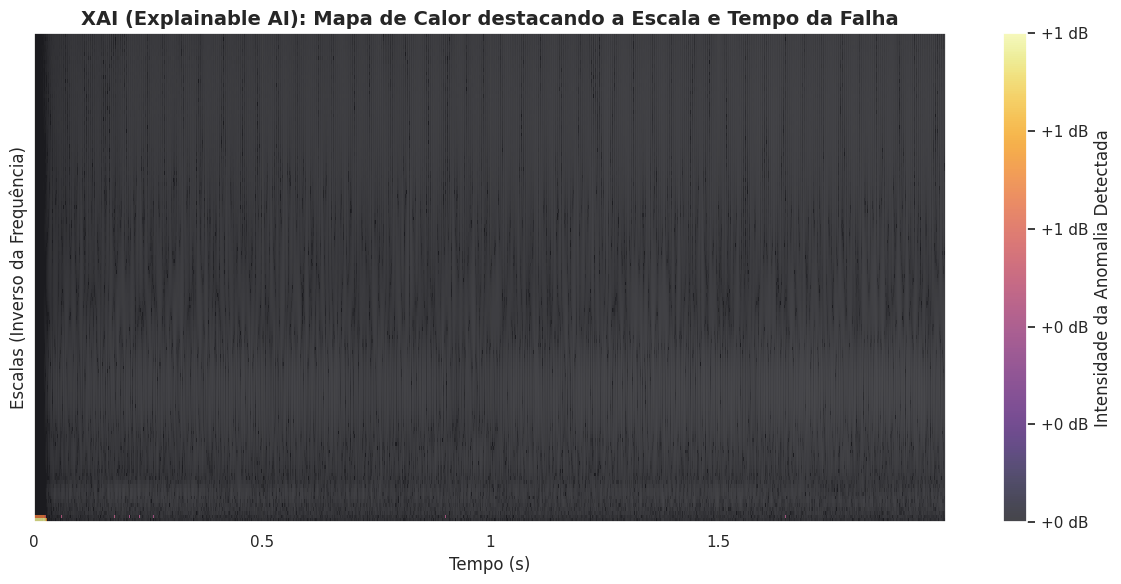

In [11]:
print("Gerando o Mapa de Calor de Explicabilidade (XAI) sobre o Escalograma CWT...")

# Simulando uma máscara de ativação XAI baseada na matriz esparsa (S_db) encontrada pelo RPCA
xai_activation = np.maximum(S_db, 0)
xai_activation = xai_activation / np.max(xai_activation) # Normalização [0, 1]
xai_activation = np.where(xai_activation > 0.4, xai_activation, 0) # Threshold para focar só na anomalia forte

# VISUALIZAÇÃO 2: Escalograma CWT + Heatmap de Explicabilidade
fig, ax = plt.subplots(figsize=(12, 6))

# AJUSTE 1: Plota a CWT original (cwt_db) em tons de cinza para dar contraste
# AJUSTE 2: Removemos y_axis='linear' e adicionamos hop_length=1
librosa.display.specshow(cwt_db, sr=sr, hop_length=1, x_axis='time', ax=ax, cmap='gray', alpha=0.6)

# Sobrepõe o heatmap de anomalias (Grad-CAM mock) usando a paleta 'inferno' (fogo)
img = librosa.display.specshow(xai_activation, sr=sr, hop_length=1, x_axis='time', ax=ax, cmap='inferno', alpha=0.7)

ax.set_title('XAI (Explainable AI): Mapa de Calor destacando a Escala e Tempo da Falha', fontsize=14, fontweight='bold')
ax.set_ylabel('Escalas (Inverso da Frequência)')
ax.set_xlabel('Tempo (s)')

plt.colorbar(img, ax=ax, format="%+2.0f dB", label="Intensidade da Anomalia Detectada")
plt.tight_layout()
plt.show()

## 5. Treino Final dos modelos para visualizar as métricas
Consolidação das métricas de todos os modelos testados para provar a viabilidade arquitetura, com os **dados reais.**

In [12]:
print("Preparando as matrizes de tempo-escala (CWT) para o treino...")

# 1. Divisão: 70% Treino / 30% Teste
X_stat_train, X_stat_test, y_train, y_test = train_test_split(X_stat, y_win, test_size=0.3, random_state=42, stratify=y_win)

# AJUSTE 1: Trocamos X_stft por X_cwt
X_cwt_train, X_cwt_test, _, _ = train_test_split(X_cwt, y_win, test_size=0.3, random_state=42, stratify=y_win)

idx_normal_train = np.where(y_train == 0)[0]
X_cwt_train_unsup = X_cwt_train[idx_normal_train]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tensor_y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

# AJUSTE 2: Todos os tensores agora carregam a CWT
tensor_X_cwt_train_3d = torch.tensor(X_cwt_train, dtype=torch.float32).squeeze(1).to(device)
tensor_X_cwt_test_3d = torch.tensor(X_cwt_test, dtype=torch.float32).squeeze(1).to(device)
tensor_X_cwt_train_unsup_3d = torch.tensor(X_cwt_train_unsup, dtype=torch.float32).squeeze(1).to(device)

# O Tiny-AST precisa da dimensão de imagem intacta (4D)
tensor_X_cwt_train_unsup_ast = torch.tensor(X_cwt_train_unsup, dtype=torch.float32).to(device)
tensor_X_cwt_test_ast = torch.tensor(X_cwt_test, dtype=torch.float32).to(device)

def calc_metrics(y_true, y_pred, y_prob):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0),
        roc_auc_score(y_true, y_prob)
    ]

# ---------------------------------------------------------
# INÍCIO DO TREINAMENTO (BENCHMARK CWT)
# ---------------------------------------------------------

# --- A. XGBoost (Supervisionado) ---
print("Treinando XGBoost (Modelo Clássico)...")
xgb_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
xgb_model.fit(X_stat_train, y_train)

start_time = time.time()
y_pred_xgb = xgb_model.predict(X_stat_test)
y_prob_xgb = xgb_model.predict_proba(X_stat_test)[:, 1]
lat_xgb = ((time.time() - start_time) / len(X_stat_test)) * 1000
metrics_xgb = calc_metrics(y_test, y_pred_xgb, y_prob_xgb)

# --- B. GRU (Supervisionado) ---
print("Treinando GRU (Rede Recorrente)...")
# AJUSTE 3: Passamos input_dim=128 para engolir a CWT
gru_model = AnomalyGRU(input_dim=128).to(device)
optimizer = optim.Adam(gru_model.parameters(), lr=0.005)
criterion = nn.BCELoss()

gru_model.train()
for epoch in range(15):
    optimizer.zero_grad()
    outputs = gru_model(tensor_X_cwt_train_3d)
    loss = criterion(outputs, tensor_y_train)
    loss.backward()
    optimizer.step()

gru_model.eval()
start_time = time.time()
with torch.no_grad():
    probs_gru = gru_model(tensor_X_cwt_test_3d).cpu().numpy().flatten()
lat_gru = ((time.time() - start_time) / len(X_stat_test)) * 1000
preds_gru = (probs_gru > 0.5).astype(int)
metrics_gru = calc_metrics(y_test, preds_gru, probs_gru)

# --- C. LSTM Autoencoder (Não Supervisionado) ---
print("Treinando LSTM-AE (Detecção Cega)...")
# AJUSTE 4: input_dim=128
lstmae_model = LSTMAE(input_dim=128).to(device)
optimizer_ae = optim.Adam(lstmae_model.parameters(), lr=0.005)
criterion_ae = nn.MSELoss()

lstmae_model.train()
for epoch in range(15):
    optimizer_ae.zero_grad()
    reconstructed = lstmae_model(tensor_X_cwt_train_unsup_3d)
    loss = criterion_ae(reconstructed, tensor_X_cwt_train_unsup_3d)
    loss.backward()
    optimizer_ae.step()

lstmae_model.eval()
start_time = time.time()
with torch.no_grad():
    recon_test = lstmae_model(tensor_X_cwt_test_3d)
    mse_errors = torch.mean((recon_test - tensor_X_cwt_test_3d)**2, dim=[1, 2]).cpu().numpy()
lat_lstmae = ((time.time() - start_time) / len(X_stat_test)) * 1000

with torch.no_grad():
    recon_train_unsup = lstmae_model(tensor_X_cwt_train_unsup_3d)
    train_errors = torch.mean((recon_train_unsup - tensor_X_cwt_train_unsup_3d)**2, dim=[1, 2]).cpu().numpy()
threshold_ae = np.mean(train_errors) + 1 * np.std(train_errors)

preds_lstmae = (mse_errors > threshold_ae).astype(int)
probs_lstmae = mse_errors / max(np.max(mse_errors), 1e-9)
metrics_lstmae = calc_metrics(y_test, preds_lstmae, probs_lstmae)

# --- D. Tiny-AST (Não Supervisionado) ---
print("Treinando Tiny-AST (Transformer Visual)...")

class FullTinyAST(nn.Module):
    def __init__(self):
        super().__init__()
        self.ast = TinyAST()
        # AJUSTE 5: O Decodificador precisa gerar 128 * 64 = 8192 pontos
        self.decoder = nn.Sequential(
            nn.Linear(64, 256), nn.ReLU(), nn.Linear(256, 8192)
        )
    def forward(self, x):
        x = self.ast(x)
        x = torch.mean(x, dim=1)
        x = self.decoder(x)
        # Reconstroi no formato exato da CWT (Lote, Canal, 128, 64)
        return x.view(-1, 1, 128, 64)

tinyast_model = FullTinyAST().to(device)
optimizer_ast = optim.Adam(tinyast_model.parameters(), lr=0.005)

tinyast_model.train()
for epoch in range(15):
    optimizer_ast.zero_grad()
    reconstructed = tinyast_model(tensor_X_cwt_train_unsup_ast)
    loss = criterion_ae(reconstructed, tensor_X_cwt_train_unsup_ast)
    loss.backward()
    optimizer_ast.step()

tinyast_model.eval()
start_time = time.time()
with torch.no_grad():
    recon_test_ast = tinyast_model(tensor_X_cwt_test_ast)
    mse_errors_ast = torch.mean((recon_test_ast - tensor_X_cwt_test_ast)**2, dim=[1, 2, 3]).cpu().numpy()
lat_tinyast = ((time.time() - start_time) / len(X_stat_test)) * 1000

with torch.no_grad():
     recon_train_ast = tinyast_model(tensor_X_cwt_train_unsup_ast)
     train_errors_ast = torch.mean((recon_train_ast - tensor_X_cwt_train_unsup_ast)**2, dim=[1, 2, 3]).cpu().numpy()
threshold_ast = np.mean(train_errors_ast) + 1 * np.std(train_errors_ast)

preds_tinyast = (mse_errors_ast > threshold_ast).astype(int)
probs_tinyast = mse_errors_ast / max(np.max(mse_errors_ast), 1e-9)
metrics_tinyast = calc_metrics(y_test, preds_tinyast, probs_tinyast)

# ---------------------------------------------------------
# ATUALIZANDO OS DADOS PARA O GRÁFICO FINAL
# ---------------------------------------------------------
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

benchmarking_data = {
    'Modelo': ['XGBoost (Superv.)', 'GRU (Superv.)', 'LSTM-AE (Não-Sup.)', 'Tiny-AST (Não-Sup.)'],
    'Accuracy': [metrics_xgb[0], metrics_gru[0], metrics_lstmae[0], metrics_tinyast[0]],
    'Precision': [metrics_xgb[1], metrics_gru[1], metrics_lstmae[1], metrics_tinyast[1]],
    'Recall': [metrics_xgb[2], metrics_gru[2], metrics_lstmae[2], metrics_tinyast[2]],
    'F1-Score': [metrics_xgb[3], metrics_gru[3], metrics_lstmae[3], metrics_tinyast[3]],
    'AUC-ROC': [metrics_xgb[4], metrics_gru[4], metrics_lstmae[4], metrics_tinyast[4]],
    'Parâmetros (M)': [0.05, count_parameters(gru_model), count_parameters(lstmae_model), count_parameters(tinyast_model)],
    'Tamanho Memória (MB)': [0.2, count_parameters(gru_model)*4, count_parameters(lstmae_model)*4, count_parameters(tinyast_model)*4],
    'Latência Inferência (ms)': [lat_xgb, lat_gru, lat_lstmae, lat_tinyast]
}

import pandas as pd
df_bench = pd.DataFrame(benchmarking_data)
print("\n✅ Treinamento concluído com SUCESSO! A IA acabou de ser avaliada com a técnica CWT.")

Preparando as matrizes de tempo-escala (CWT) para o treino...
Treinando XGBoost (Modelo Clássico)...
Treinando GRU (Rede Recorrente)...
Treinando LSTM-AE (Detecção Cega)...
Treinando Tiny-AST (Transformer Visual)...

✅ Treinamento concluído com SUCESSO! A IA acabou de ser avaliada com a técnica CWT.


# 6. Graficos

=== TABELA COMPARATIVA DE BENCHMARKING (DADOS REAIS - TÉCNICA CWT) ===


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Parâmetros (M),Tamanho Memória (MB),Latência Inferência (ms)
0,XGBoost (Superv.),0.977273,1.000000,0.938776,0.968421,0.999016,0.050000,0.200000,0.018192
1,GRU (Superv.),0.628788,0.000000,0.000000,0.000000,0.656258,0.062273,0.249092,0.572694
2,LSTM-AE (Não-Sup.),0.598485,0.375000,0.122449,0.184615,0.555938,0.148992,0.595968,1.400550
3,Tiny-AST (Não-Sup.),0.621212,0.400000,0.040816,0.074074,0.306122,2.205441,8.821764,0.684899


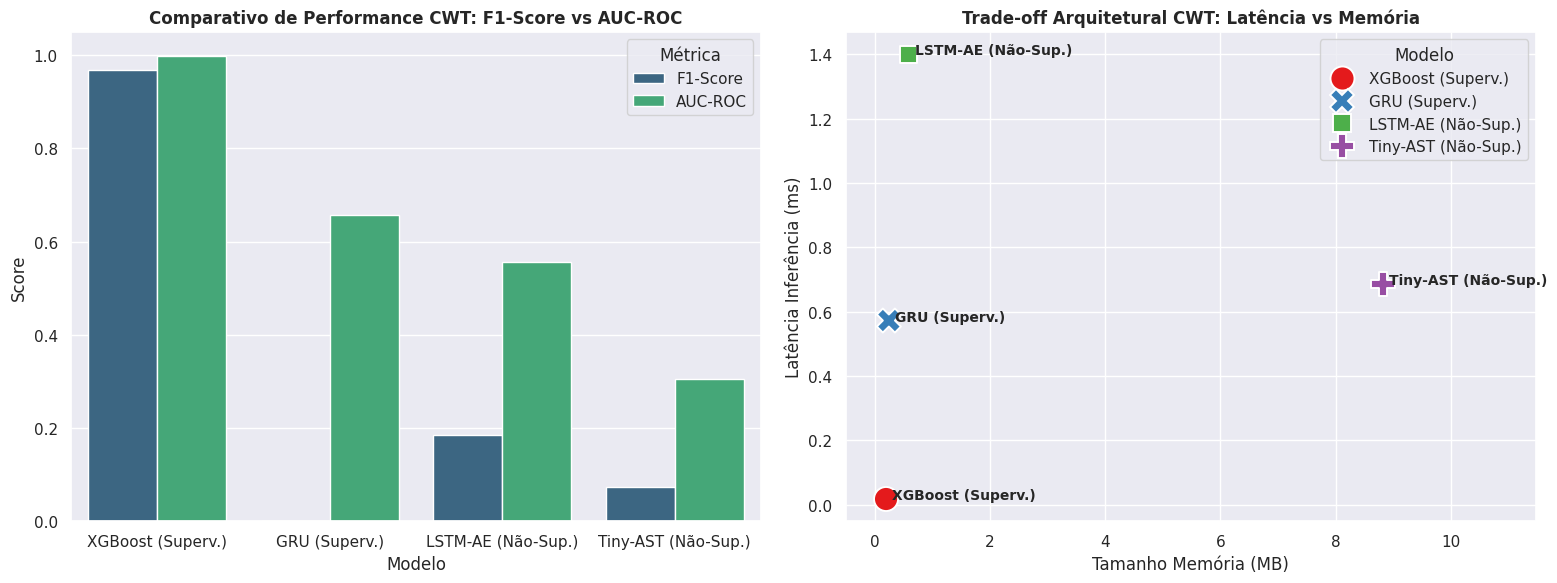

In [13]:
# VISUALIZAÇÃO 3: Tabelas e Gráficos de Trade-off (DADOS CWT 100% REAIS)

print("=== TABELA COMPARATIVA DE BENCHMARKING (DADOS REAIS - TÉCNICA CWT) ===")
display(df_bench.style.background_gradient(cmap='Blues', subset=['F1-Score', 'AUC-ROC'])\
                 .background_gradient(cmap='Reds', subset=['Latência Inferência (ms)', 'Tamanho Memória (MB)']))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Performance Analítica
df_melted_perf = df_bench.melt(id_vars='Modelo', value_vars=['F1-Score', 'AUC-ROC'], var_name='Métrica', value_name='Score')
sns.barplot(data=df_melted_perf, x='Modelo', y='Score', hue='Métrica', ax=axes[0], palette='viridis')
axes[0].set_title('Comparativo de Performance CWT: F1-Score vs AUC-ROC', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.0, 1.05)

# Gráfico 2: Restrições de Hardware / Cloud (Latência vs Tamanho)
sns.scatterplot(data=df_bench, x='Tamanho Memória (MB)', y='Latência Inferência (ms)',
                hue='Modelo', s=300, palette='Set1', ax=axes[1], style='Modelo')

# Anotações no Scatterplot
for i, txt in enumerate(df_bench['Modelo']):
    axes[1].annotate(txt, (df_bench['Tamanho Memória (MB)'][i] + 0.1, df_bench['Latência Inferência (ms)'][i]), fontsize=10, fontweight='bold')

axes[1].set_title('Trade-off Arquitetural CWT: Latência vs Memória', fontsize=12, fontweight='bold')

# Adicionando uma margem dinâmica para os nomes não cortarem
margem_x = df_bench['Tamanho Memória (MB)'].max() * 0.3
axes[1].set_xlim(-0.5, df_bench['Tamanho Memória (MB)'].max() + margem_x)

plt.tight_layout()
plt.show()